## Task 1

**Choice of dataset**: [Kaggle: Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

The dataset contains **7,200 human brain MRI images** categorized into four distinct classes:

* **Glioma**
* **Meningioma**
* **Pituitary tumor**
* **No tumor**

The dataset is structured into training and testing sets with balanced class distributions to ensure model reliability.

### Dataset Structure

| Category | Training Set (5,600 images) | Testing Set (1,600 images) |
| :--- | :--- | :--- |
| **Glioma** | 1,400 | 400 |
| **Meningioma** | 1,400 | 400 |
| **Pituitary** | 1,400 | 400 |
| **No Tumor** | 1,400 | 400 |

#### Directory Hierarchy
```text
Brain_Tumor_MRI/
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── pituitary/
│   └── notumor/
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── pituitary/
    └── notumor/
```

#### Part 1

In [143]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


In [138]:
train_dir = 'Brain_Tumor_MRI/Training/'
test_dir = 'Brain_Tumor_MRI/Testing/'
classes = ["glioma", "meningioma", "notumor", "pituitary"]

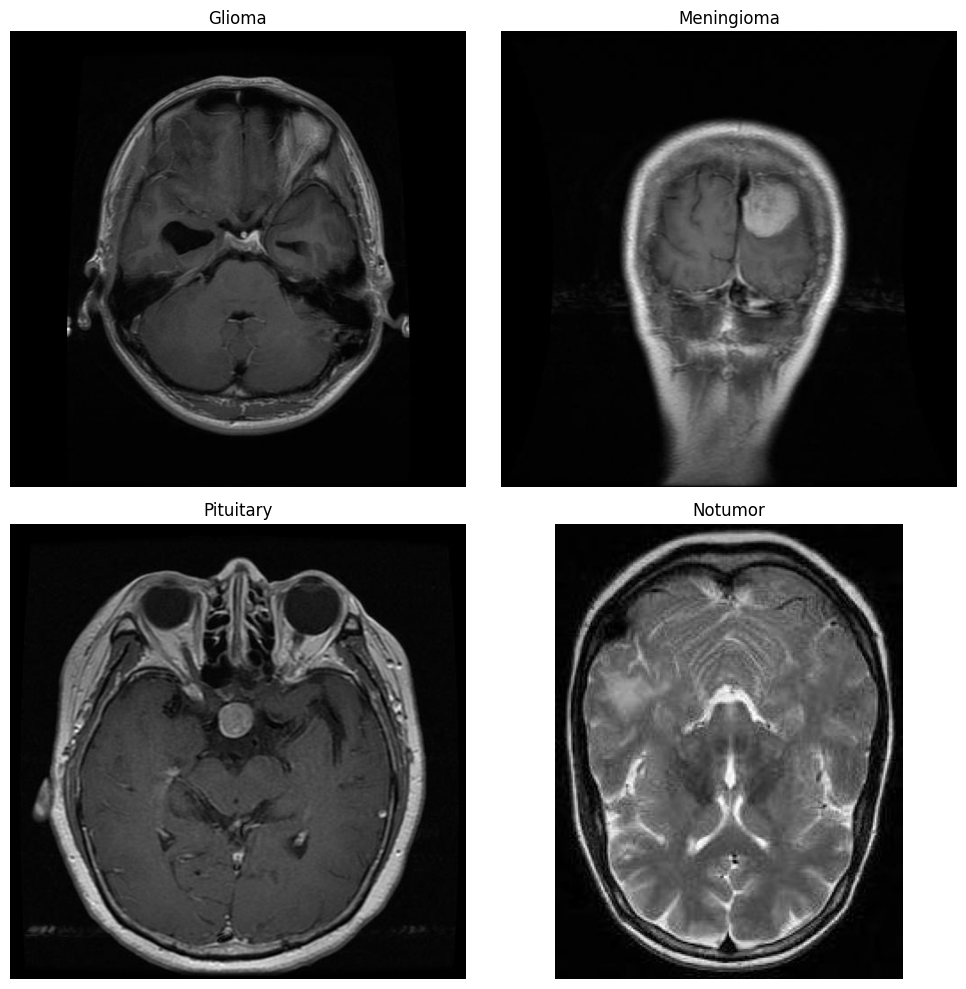

In [110]:
# Vizualize the 4 different types of Brain Tumor
plt.figure(figsize=(10, 10))
for i, label in enumerate(classes):
    label_path = os.path.join(train_dir, label)    
    first_image_name = os.listdir(label_path)[0]
    img_path = os.path.join(label_path, first_image_name)
    # MRIs look best in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    ax = plt.subplot(2, 2, i + 1)
    ax.imshow(img, cmap='gray') 
    ax.set_title(label.capitalize())
    ax.axis('off')

plt.tight_layout()
plt.show()

In [111]:
# Set to store unique image sizes
unique_sizes = set()
total_images = 0

for label in classes:
    label_path = os.path.join(train_dir, label)
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        img = cv2.imread(img_path)
        unique_sizes.add(img.shape[:2]) # (height, width)
        total_images += 1

In [112]:
print(f"Total training images: {total_images}")

if len(unique_sizes) > 1:
    print("The image sizes are NOT uniform")
else:
    print(f"All images are the exact same size: {list(unique_sizes)[0]}")

Total training images: 5600
The image sizes are NOT uniform


In [113]:
DEVICE = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {DEVICE}")

Device used: cuda:2


In [114]:
# Hyperparameters
BATCH_SIZE = 32
HIDDEN_NEURONS = 512
LEARNING_RATE = 0.001
EPOCHS = 10

In [115]:
# We will resize all the images to be of the size 224 x 224 (industry standard)
# To avoid distortions, we will pad the image to a square first, and then resize it. 
# (This adds black borders to the shorter sides so the aspect ratio is perfectly preserved)

class SquarePad:
    def __call__(self, image):
        # image.size returns (width, height) for PIL Images
        w, h = image.size
        max_dim = max(w, h)
        
        # Calculate padding for left, top, right, bottom
        horizontal_padding = int((max_dim - w) / 2)
        vertical_padding = int((max_dim - h) / 2)
        padding = (horizontal_padding, vertical_padding, max_dim - w - horizontal_padding, max_dim - h - vertical_padding)
        
        # Apply the pad (0 represents black pixels)
        return ImageOps.expand(image, border=padding, fill=0)

In [116]:
# Data Transforms Pipeline
data_transforms = transforms.Compose([
    SquarePad(),                           # Step 1: Make it a perfect square without distortion
    transforms.Resize((224, 224)),         # Step 2: Now safely resize the square to 224x224
    transforms.ToTensor(),                 # Step 3: Convert to PyTorch Tensor
    transforms.Normalize(                  # Step 4: Normalize the pixel values to have a mean of 0 and std of 1 (helps CNNs learn faster)
        mean=[0.485, 0.456, 0.406],        # these are the industry standard values for each channel
        std=[0.229, 0.224, 0.225]
    ) 
])

In [117]:
# datasets.ImageFolder looks at your subfolders and sorts them alphabetically
# which means the classes will be:
# 'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3
train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms)

In [118]:
# Split train/val
total_train_size = len(train_dataset)
val_size = int(0.10 * total_train_size)
train_size = total_train_size - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
total_size = train_size + val_size + len(test_dataset)

In [119]:
print(f"Train size: {train_size} ({train_size / total_size:.2%})")
print(f"Val size:   {val_size} ({val_size / total_size:.2%})")
print(f"Test size:  {len(test_dataset)} ({len(test_dataset) / total_size:.2%})")

Train size: 5040 (70.00%)
Val size:   560 (7.78%)
Test size:  1600 (22.22%)


In [120]:
# Create loaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [121]:

# VERIFY the shape of a single batch and the class mapping
images, labels = next(iter(train_loader))
print(f"Batch Image Shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Batch Label Shape: {labels.shape}") # Should be [32]
print(f"Class mapping: {train_dataset.class_to_idx}")

Batch Image Shape: torch.Size([32, 3, 224, 224])
Batch Label Shape: torch.Size([32])
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [122]:
# reverse mapping for later to look up the actual class name using the label index
idx_to_class = {
    0: 'glioma',
    1: 'meningioma',
    2: 'notumor',
    3: 'pituitary'
}

In [123]:
def imshow_unnormalized(img):
    # PyTorch tensors are ordered (Channels, Height, Width) -> (3, 224, 224)
    # Matplotlib expects (Height, Width, Channels) -> (224, 224, 3)
    img = img.numpy().transpose((1, 2, 0)) 
    
    # Reverse the normalization math: image = (image * std) + mean
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean 

    # Clip values to ensure they are strictly between 0 and 1
    img = np.clip(img, 0, 1) 
    plt.imshow(img)

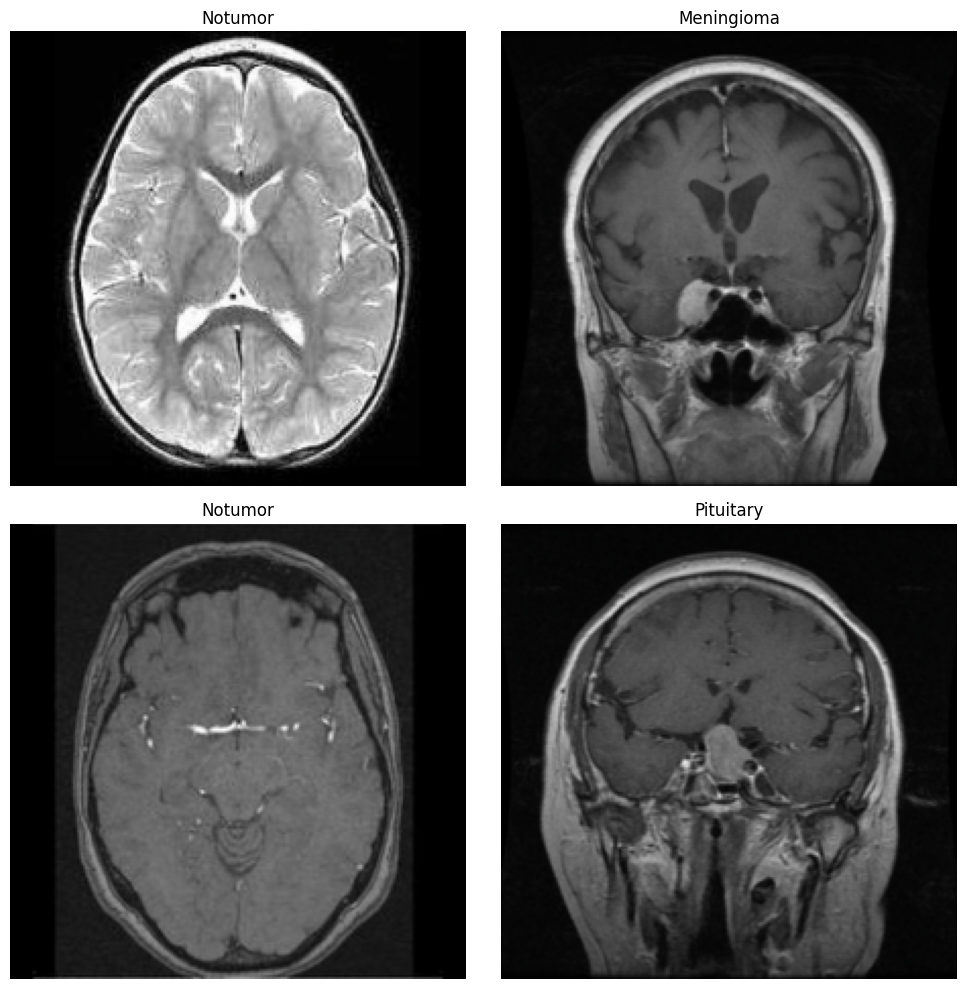

In [124]:
# VERIFY that the loaded images are not distorted
images_check = images[:4]
labels_check = labels[:4]

plt.figure(figsize=(10, 10))
for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    imshow_unnormalized(images[i])
    class_name = idx_to_class[labels[i].item()]
    ax.set_title(class_name.capitalize())
    ax.axis('off')

plt.tight_layout()
plt.show()

In [125]:
class BrainTumorCNN(nn.Module):
    def __init__(self, hidden_neurons, num_classes=4):
        super(BrainTumorCNN, self).__init__()
        
        # PHASE 1: FEATURE LEARNING
        # Input assumes an RGB image resized to 224 x 224 x 3
        
        # Layer 1: Apply 16 filters, creating 16 feature maps.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        # Layer 2: Takes the 16 feature maps from before, applies 32 filters.
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Layer 3: Takes 32 feature maps, applies 64 filters. 
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # We define a 2x2 Max pooling window that slides over the image.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # After Pool 1: Cut size in half to 112 x 112
        # After Pool 2: Cut size in half to 56 x 56
        # After Pool 3: Cut size in half to 28 x 28

        # PHASE 2: CLASSIFICATION

        # Flattened size: 64 channels * 28 height * 28 width
        flattened_size = 64 * 28 * 28
        
        # 1 hidden layer
        self.fc1 = nn.Linear(in_features=flattened_size, out_features=hidden_neurons)
        
        # Add Dropout to prevent overfitting
        self.dropout = nn.Dropout(p=0.5)
        
        # Final classification layer
        self.fc2 = nn.Linear(in_features=hidden_neurons, out_features=num_classes)

    def forward(self, x):
        # Convolution -> ReLU -> Max Pooling
        # Convolution blocks (224 -> 112 -> 56 -> 28)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten the tensor
        x = torch.flatten(x, 1)
        
        # Fully connected layers with dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [126]:
model_cnn = BrainTumorCNN(hidden_neurons = HIDDEN_NEURONS,num_classes=4).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)

In [127]:
# TRAINING PHASE
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = 'best_cnn_brain_tumor_model.pth'

In [128]:
print("Training Phase")
for epoch in range(EPOCHS):
    model_cnn.train()
    running_loss = 0.0
    correct = 0
    total_images = 0
    
    for X_t, y_t in train_loader:
        X_t, y_t = X_t.to(DEVICE), y_t.to(DEVICE)
        # Clear old gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model_cnn(X_t)
        # Calculate loss
        loss = criterion(outputs, y_t)
        # Backward pass
        loss.backward()
        # Update weights
        optimizer.step()
        
        running_loss += loss.item() * X_t.size(0) # for the batch
        _, predicted = torch.max(outputs, dim=1)
        total_images += y_t.size(0) 
        correct += (predicted == y_t).sum().item()
        
    epoch_train_loss = running_loss / total_images
    epoch_train_acc = correct / total_images
    
    # VALIDATION PHASE
    model_cnn.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total_images = 0
    
    with torch.no_grad():
        for X_v, y_v in valid_loader:
            X_v, y_v = X_v.to(DEVICE), y_v.to(DEVICE)
            outputs = model_cnn(X_v)
            loss = criterion(outputs, y_v)
            
            val_running_loss += loss.item() * X_v.size(0)
            _, predicted = torch.max(outputs, dim=1)
            val_total_images += y_v.size(0)
            val_correct += (predicted == y_v).sum().item()
            
    epoch_val_loss = val_running_loss / val_total_images
    epoch_val_acc = val_correct / val_total_images
    
    # Save history for plots
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # Check for new best model ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model_cnn.state_dict(), best_model_path)
        print("Found new best model at Epoch", epoch+1) 
        print(f"    Validation Accuracy: {epoch_val_acc:.4f}")

Training Phase


Epoch 1 | Train Loss: 0.6857 | Val Loss: 0.3726
Found new best model at Epoch 1
    Validation Accuracy: 0.8589
Epoch 2 | Train Loss: 0.3543 | Val Loss: 0.2354
Found new best model at Epoch 2
    Validation Accuracy: 0.9161
Epoch 3 | Train Loss: 0.2082 | Val Loss: 0.2271
Epoch 4 | Train Loss: 0.1479 | Val Loss: 0.1416
Found new best model at Epoch 4
    Validation Accuracy: 0.9482
Epoch 5 | Train Loss: 0.0885 | Val Loss: 0.2023
Epoch 6 | Train Loss: 0.0543 | Val Loss: 0.2231
Epoch 7 | Train Loss: 0.0506 | Val Loss: 0.1991
Epoch 8 | Train Loss: 0.0330 | Val Loss: 0.2385
Epoch 9 | Train Loss: 0.0351 | Val Loss: 0.1593
Found new best model at Epoch 9
    Validation Accuracy: 0.9554
Epoch 10 | Train Loss: 0.0211 | Val Loss: 0.1967


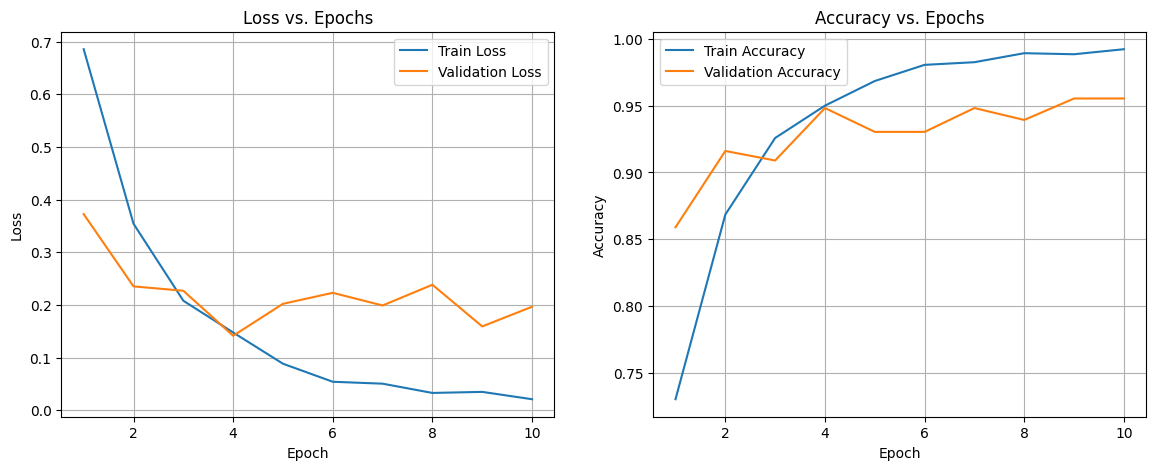

In [132]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training and Validation Loss
axs[0].plot(range(1, EPOCHS+1), history['train_loss'], label='Train Loss')
axs[0].plot(range(1, EPOCHS+1), history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss vs. Epochs')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Training and Validation Accuracy
axs[1].plot(range(1, EPOCHS+1), history['train_acc'], label='Train Accuracy')
axs[1].plot(range(1, EPOCHS+1), history['val_acc'], label='Validation Accuracy')
axs[1].set_title('Accuracy vs. Epochs')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.show()

In [ ]:

# Load the best weights into the model
model_cnn.load_state_dict(torch.load(best_model_path))
model_cnn.eval()

y_preds = []
y_true = []

# TESTING PHASE
with torch.no_grad():
    for X_t, y_t in test_loader:
        X_t = X_t.to(DEVICE)
        outputs = model_cnn(X_t)
        _, predicted = torch.max(outputs, dim=1) 
        y_preds.extend(predicted.cpu().numpy())
        y_true.extend(y_t.cpu().numpy())

In [140]:

print(classification_report(y_true, y_preds, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.92      0.76      0.83       400
  meningioma       0.77      0.89      0.83       400
     notumor       0.92      0.98      0.95       400
   pituitary       0.94      0.90      0.92       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



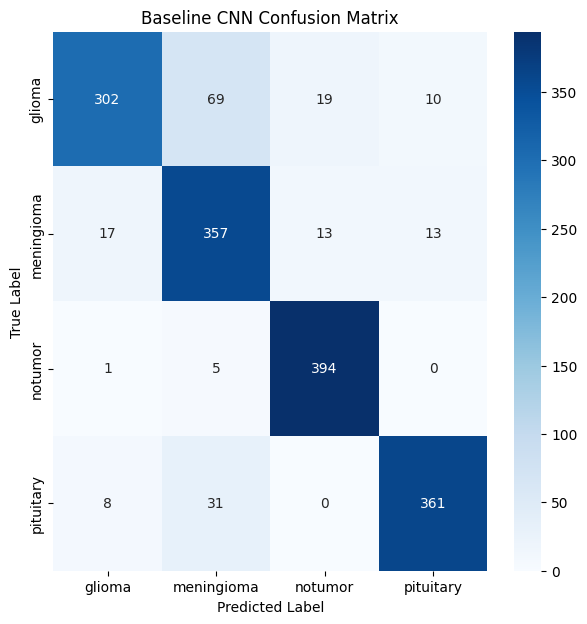

In [146]:
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Baseline CNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

##### Baseline CNN Report

**Data Preprocessing**:

Images were pre-processed using a SquarePad strategy. This added black borders to preserve the original aspect ratio of the MRI scans before resizing to the industry standard **$224 \times 224 \times 3$**. Normalization was applied to the pixels using industry standard mean and standard deviation.


**Architecture Design**:

* Pattern Choice: A 3-layer stack of **Conv + ReLU + MaxPooling**. They provide enough depth to move from single edge detection (layer 1) to complex texture extraction by layer 3. Max pooling was used after every conolution to reduce the spatial dimentions ($224 \rightarrow 112 \rightarrow 56 \rightarrow 28$).

* Classification: A hidden dense layer (512 neurons) was used to learn non-linear combinations of the **$50,176$** flattened features.

* Regularization: A Dropout (0.5) layer was placed before the final output to mitigate the risk of overfitting.

**Training**:

The model was trained for 10 epochs using the Adam optimizer and Cross-Entropy Loss.

**Analysis of Metrics & Curves**:

* **Overfitting:** The **Loss vs. Epochs** plot shows that after **Epoch 4**, training loss continues to drop toward zero while validation loss begins to rise and fluctuate. This indicates the model began memorizing the training set noise, however we saved the model weights at that epoch for the testing phase.

* **Confusion**: The model struggles most with **Glioma**, misclassifying **$69$** instances as **Meningioma**. This is likely due to the visual similarities between these two tumor types.

* **Detection Strength:** The model is very good at identifying healthy brains (**No Tumor**), with only **6** false negative in the test set.